imput all libraries :

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns             
from sklearn.model_selection import train_test_split   
from sklearn.preprocessing import StandardScaler       
from sklearn.preprocessing import OneHotEncoder        
from sklearn.linear_model import LinearRegression      
from sklearn.tree import DecisionTreeRegressor        
from sklearn.ensemble import RandomForestRegressor 
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

Load and Explore Data

In [2]:
Data = pd.read_excel("Processed_Flipdata.xlsx")

In [3]:
print(Data.head())

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_  Prize  
0  Unisoc Spreadtrum SC9863A1   7299  
1  Unisoc Spreadtrum SC9863A1   7299  
2     Qualcomm Snapdragon 680  11999  
3          Mediatek Helio A22   5649  
4                         G37   8999  


In [4]:
print(Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None


In [5]:
print(Data.describe())

       Unnamed: 0      Memory         RAM     Battery_     AI Lens  \
count  541.000000  541.000000  541.000000   541.000000  541.000000   
mean   289.711645  110.550832    5.397412  4871.587800    0.062847   
std    182.359185   60.600694    1.984923   780.148862    0.242911   
min      0.000000   16.000000    2.000000   800.000000    0.000000   
25%    135.000000   64.000000    4.000000  5000.000000    0.000000   
50%    273.000000  128.000000    6.000000  5000.000000    0.000000   
75%    434.000000  128.000000    8.000000  5000.000000    0.000000   
max    642.000000  256.000000    8.000000  7000.000000    1.000000   

       Mobile Height         Prize  
count     541.000000    541.000000  
mean       16.431201  16228.375231  
std         2.523553  10793.588322  
min         4.500000    920.000000  
25%        16.510000   9290.000000  
50%        16.710000  13499.000000  
75%        16.940000  19280.000000  
max        41.940000  80999.000000  


Data Preprocessing

In [6]:

Data = Data[(Data['Battery_'] >= 1000) & (Data['Rear Camera'] != '0MP')]


In [7]:

Data = pd.get_dummies(Data, columns=['Model','Colour','Processor_'], drop_first=True)

In [8]:
Data['Rear Camera'] = Data['Rear Camera'].str.replace('MP','').astype(float)
Data['Front Camera'] = Data['Front Camera'].str.replace('MP','').astype(float)


In [9]:
X = Data.drop('Prize', axis=1)
y = Data['Prize']

Feature Extraction

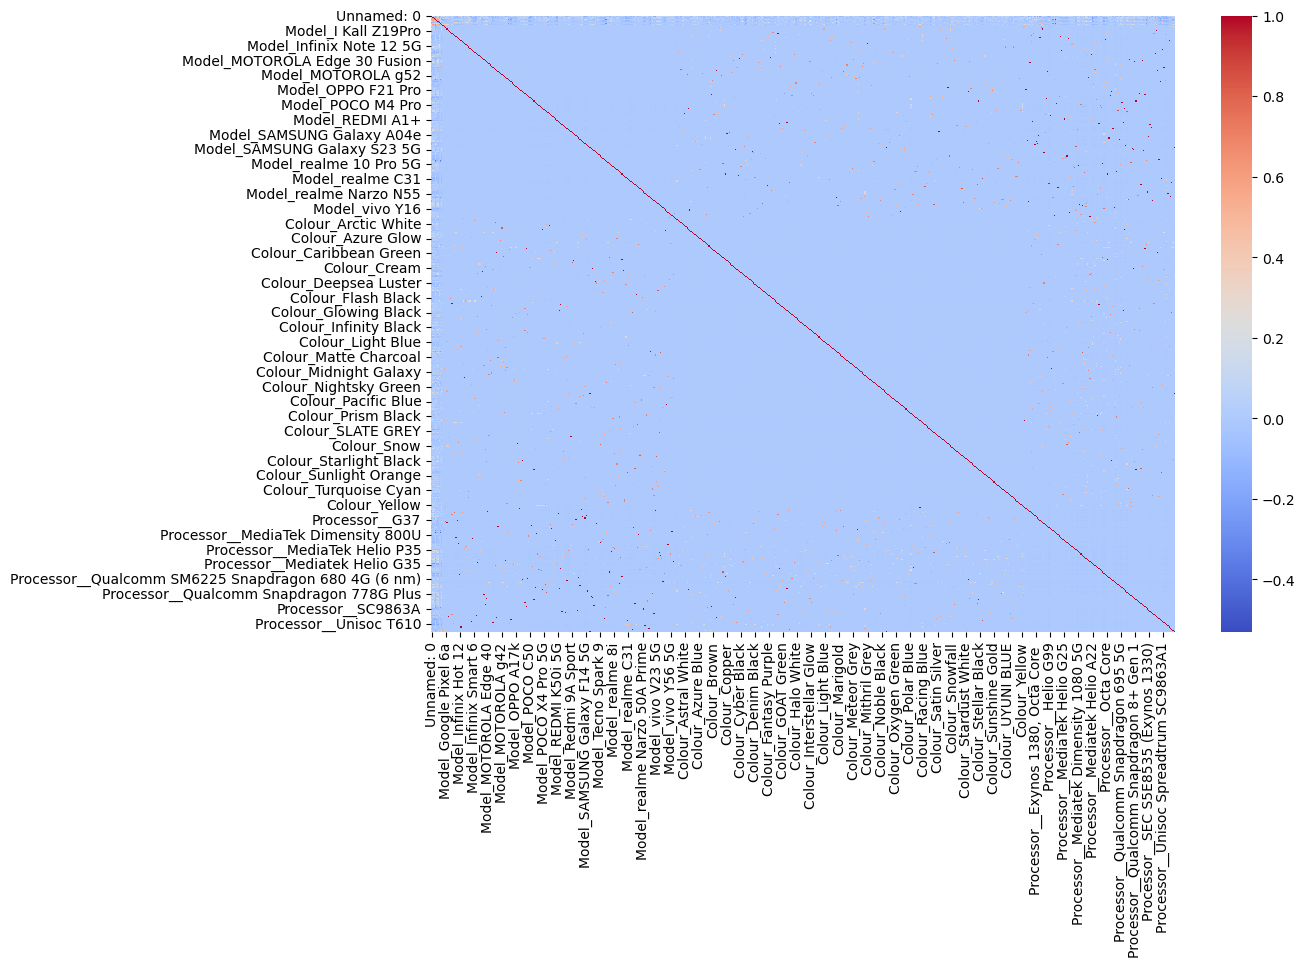

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(Data.corr(), annot=False, cmap='coolwarm')
plt.show()

Model Building

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [15]:
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2167.762122641509
RMSE: 4770.045458284711


Feature Importance

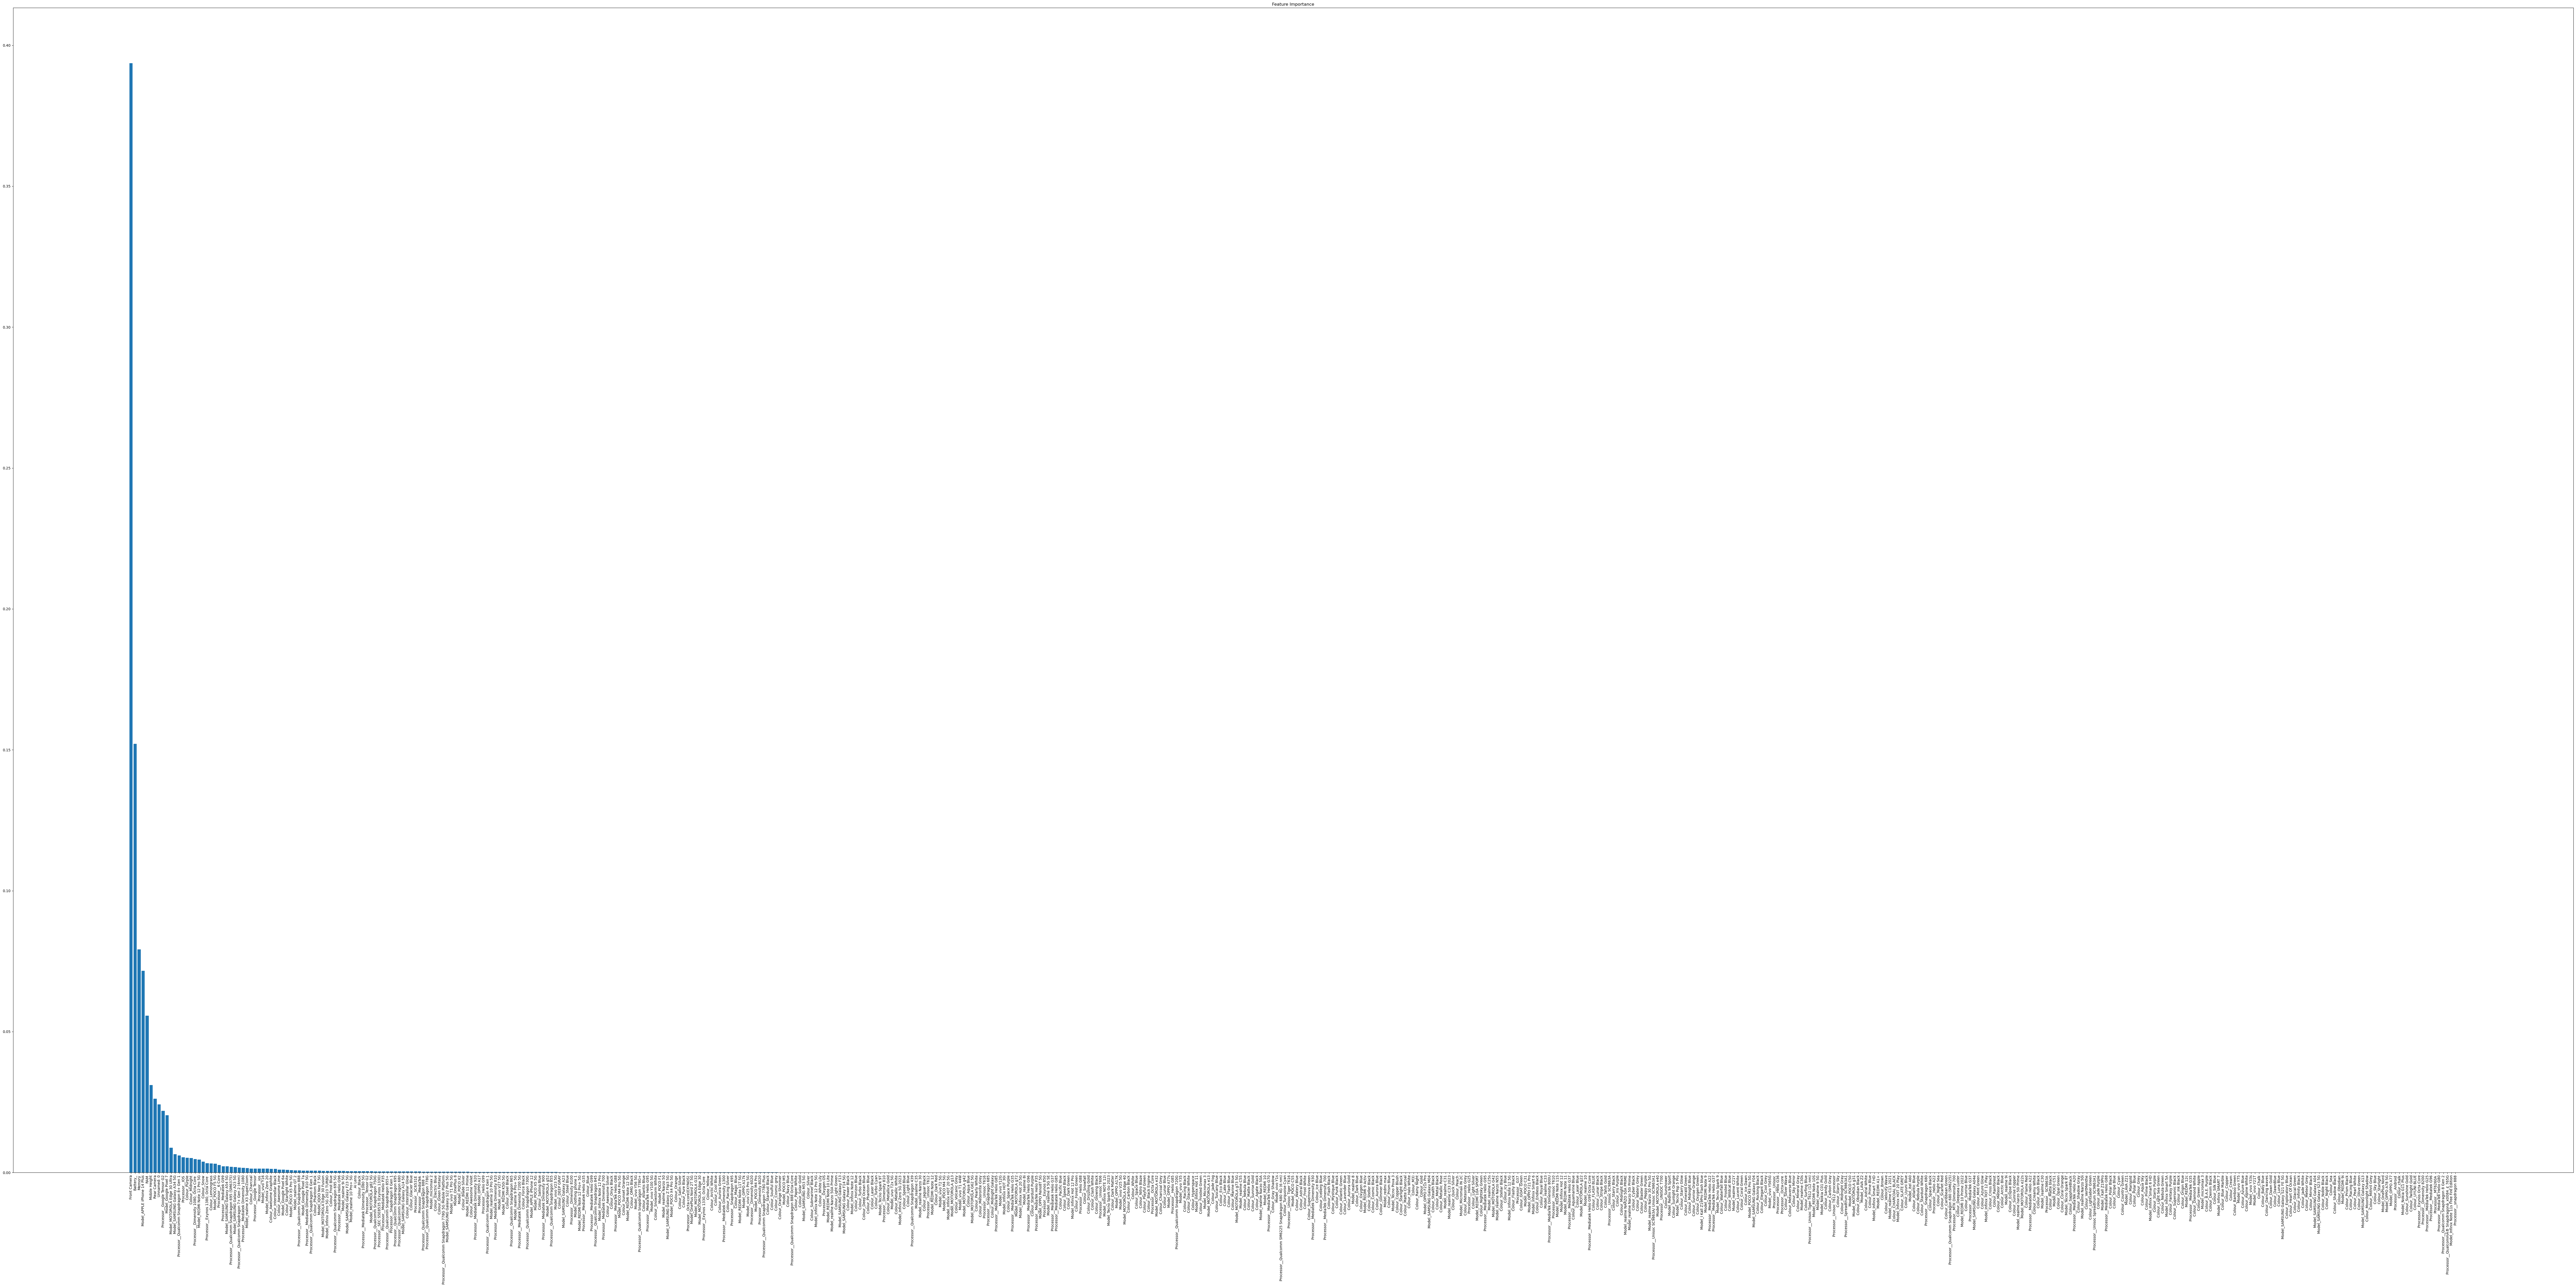

In [24]:
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(100,50)) 
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


VISUALIZATIONS :

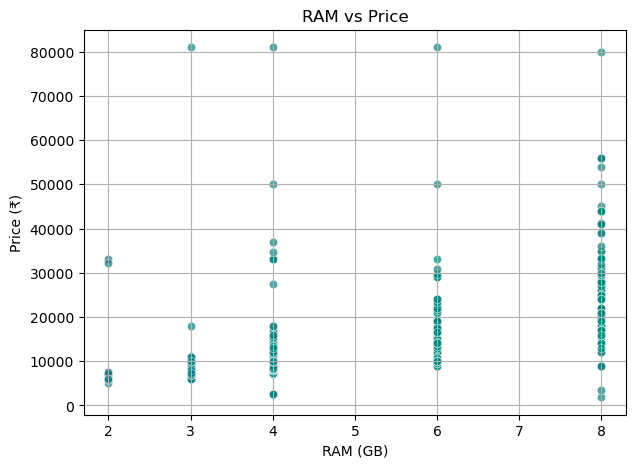

In [25]:
# RAM vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=Data['RAM'], y=Data['Prize'], alpha=0.7, color='teal')
plt.title("RAM vs Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

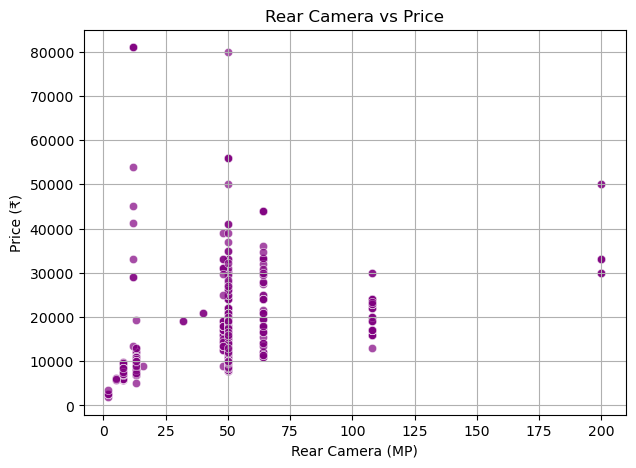

In [26]:
# Rear Camera vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=Data['Rear Camera'], y=Data['Prize'], alpha=0.7, color='purple')
plt.title("Rear Camera vs Price")
plt.xlabel("Rear Camera (MP)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

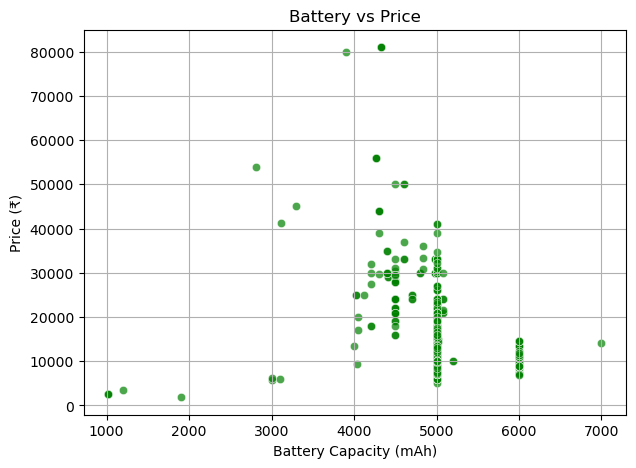

In [27]:
# Battery vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=Data['Battery_'], y=Data['Prize'], alpha=0.7, color='green')
plt.title("Battery vs Price")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

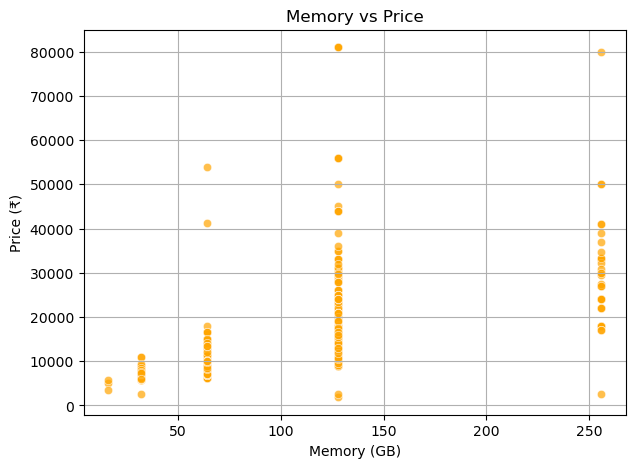

In [28]:
# Memory vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=Data['Memory'], y=Data['Prize'], alpha=0.7, color='orange')
plt.title("Memory vs Price")
plt.xlabel("Memory (GB)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

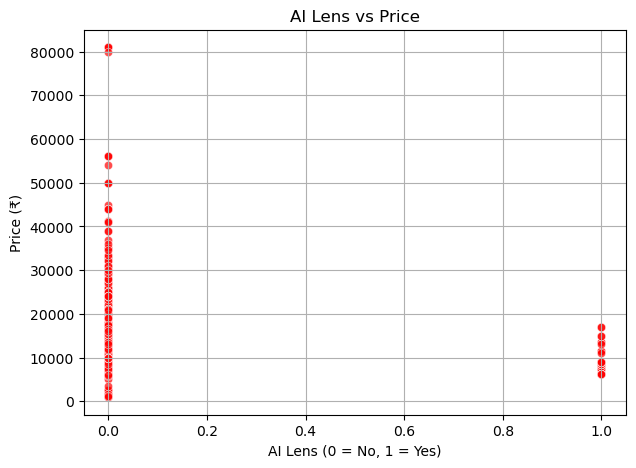

In [33]:
# AI Lens vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=Data['AI Lens'], y=Data['Prize'], alpha=0.7, color='red')
plt.title("AI Lens vs Price")
plt.xlabel("AI Lens (0 = No, 1 = Yes)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

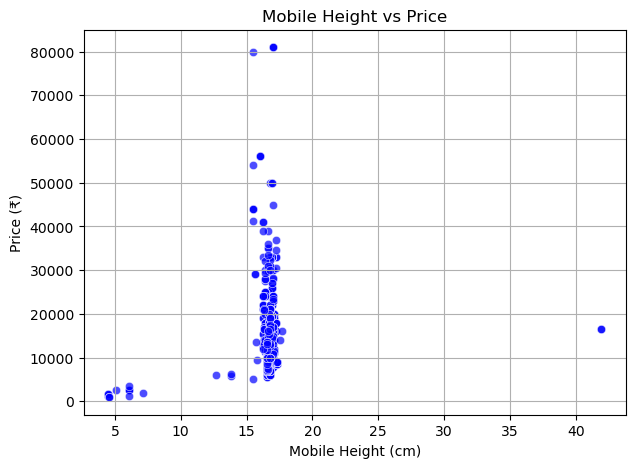

In [34]:
# Mobile Height vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=Data['Mobile Height'], y=Data['Prize'], alpha=0.7, color='blue')
plt.title("Mobile Height vs Price")
plt.xlabel("Mobile Height (cm)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()